In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df=pd.read_csv('Advertising.csv')

In [4]:
df.head(2)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4


In [5]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [6]:
df.drop(columns="Unnamed: 0",inplace=True)

In [7]:
df.head(2)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4


In [8]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [9]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [10]:
x=df[['TV', 'Radio', 'Newspaper']]
y=df['Sales']

In [11]:
df['TV'].corr(df['Radio'])

np.float64(0.054808664465830034)

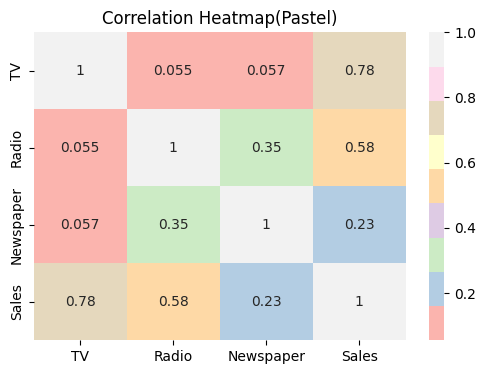

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(df.corr(), annot=True, cmap='Pastel1')

plt.title("Correlation Heatmap(Pastel)")
plt.show()

****train the data ****

In [13]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=100)

In [14]:
from sklearn.linear_model import LinearRegression
mlr=LinearRegression()
mlr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print("Intercept: ", mlr.intercept_)
print("Coefficients:")
list(zip(x, mlr.coef_))

Intercept:  3.528604528657855
Coefficients:


[('TV', np.float64(0.04541460351552472)),
 ('Radio', np.float64(0.1932378588249812)),
 ('Newspaper', np.float64(-0.008971202419624902))]

In [16]:
y_pred=mlr.predict(x_test)
print("Prediction value:{}".format(y_pred))

Prediction value:[17.35458233 14.46228251 14.61274306 14.24936889 12.67083596  9.19507734
 11.93858026 19.85906332  9.46065622  5.85461987 16.750776   18.64145477
 13.22978394 17.49377166 18.71454614 12.73920101  4.81852093 12.14406269
 16.87758122 13.89627112 17.85620949 17.86482519 21.37779011 15.56718348
 10.49121911  7.08832067 14.8802643  11.80779316  7.30139576 14.86089951
 13.27531846  9.24627098 12.93508786 14.58481297 17.29077784 15.76523774
 15.65313013  7.4341863  18.32078042 14.07457981 10.8009187  12.6575032
 23.09883296 14.70999307 15.54596055 19.61801295  7.02009673 18.90166122
 17.58998592 24.2549401   9.91101784 20.88112293 15.65717795 16.05704169
 12.26732274 20.88162909 15.96949785 15.08472123 16.45229762 12.91467125
 16.92743282 17.44664977 25.17824328 12.89107607 17.14659214 10.03135152
 18.43088192 14.66521049 14.02529582 21.56924725 16.3266549   6.75558761
 10.78493403 18.01349508 13.21252439 19.45278904  4.90098281 18.63055548
 15.81405183 16.57654901 21.2306236

In [17]:
mlr_diff=pd.DataFrame({"Actual value":y_test,"Predicated value":y_pred})
mlr_diff.head(2)

,Actual value,Predicated value
168,17.1,17.354582
112,14.1,14.462283


In [20]:
mlr_diff["Error"]=mlr_diff['Actual value']-mlr_diff['Predicated value']

In [21]:
mlr_diff.head(2)

,Actual value,Predicated value,Error
168,17.1,17.354582,-0.254582
112,14.1,14.462283,-0.362283


In [ ]:

from sklearn import metrics
meanAbberr=metrics.mean_absolute_error(y_test,y_pred)
meanSqerr=metrics.mean_squared_error(y_test,y_pred)
rootmeansq=np.sqrt(metrics.mean_squared_error(y_test,y_pred))
print('R sqaures:{:.2f}'.format(mlr.score(x,y)*100))
print("mean square error",meanSqerr)
print("mean absolute error",meanAbberr)
print("root square",rootmeansq)

R sqaures:89.01
mean square error 3.3792519594587005
mean absolute error 1.3447230959500467
root square 1.8382741796203037
